# <CENTER> **PROJECT: Fashion-MNIST Classification (building a classifier)**

---

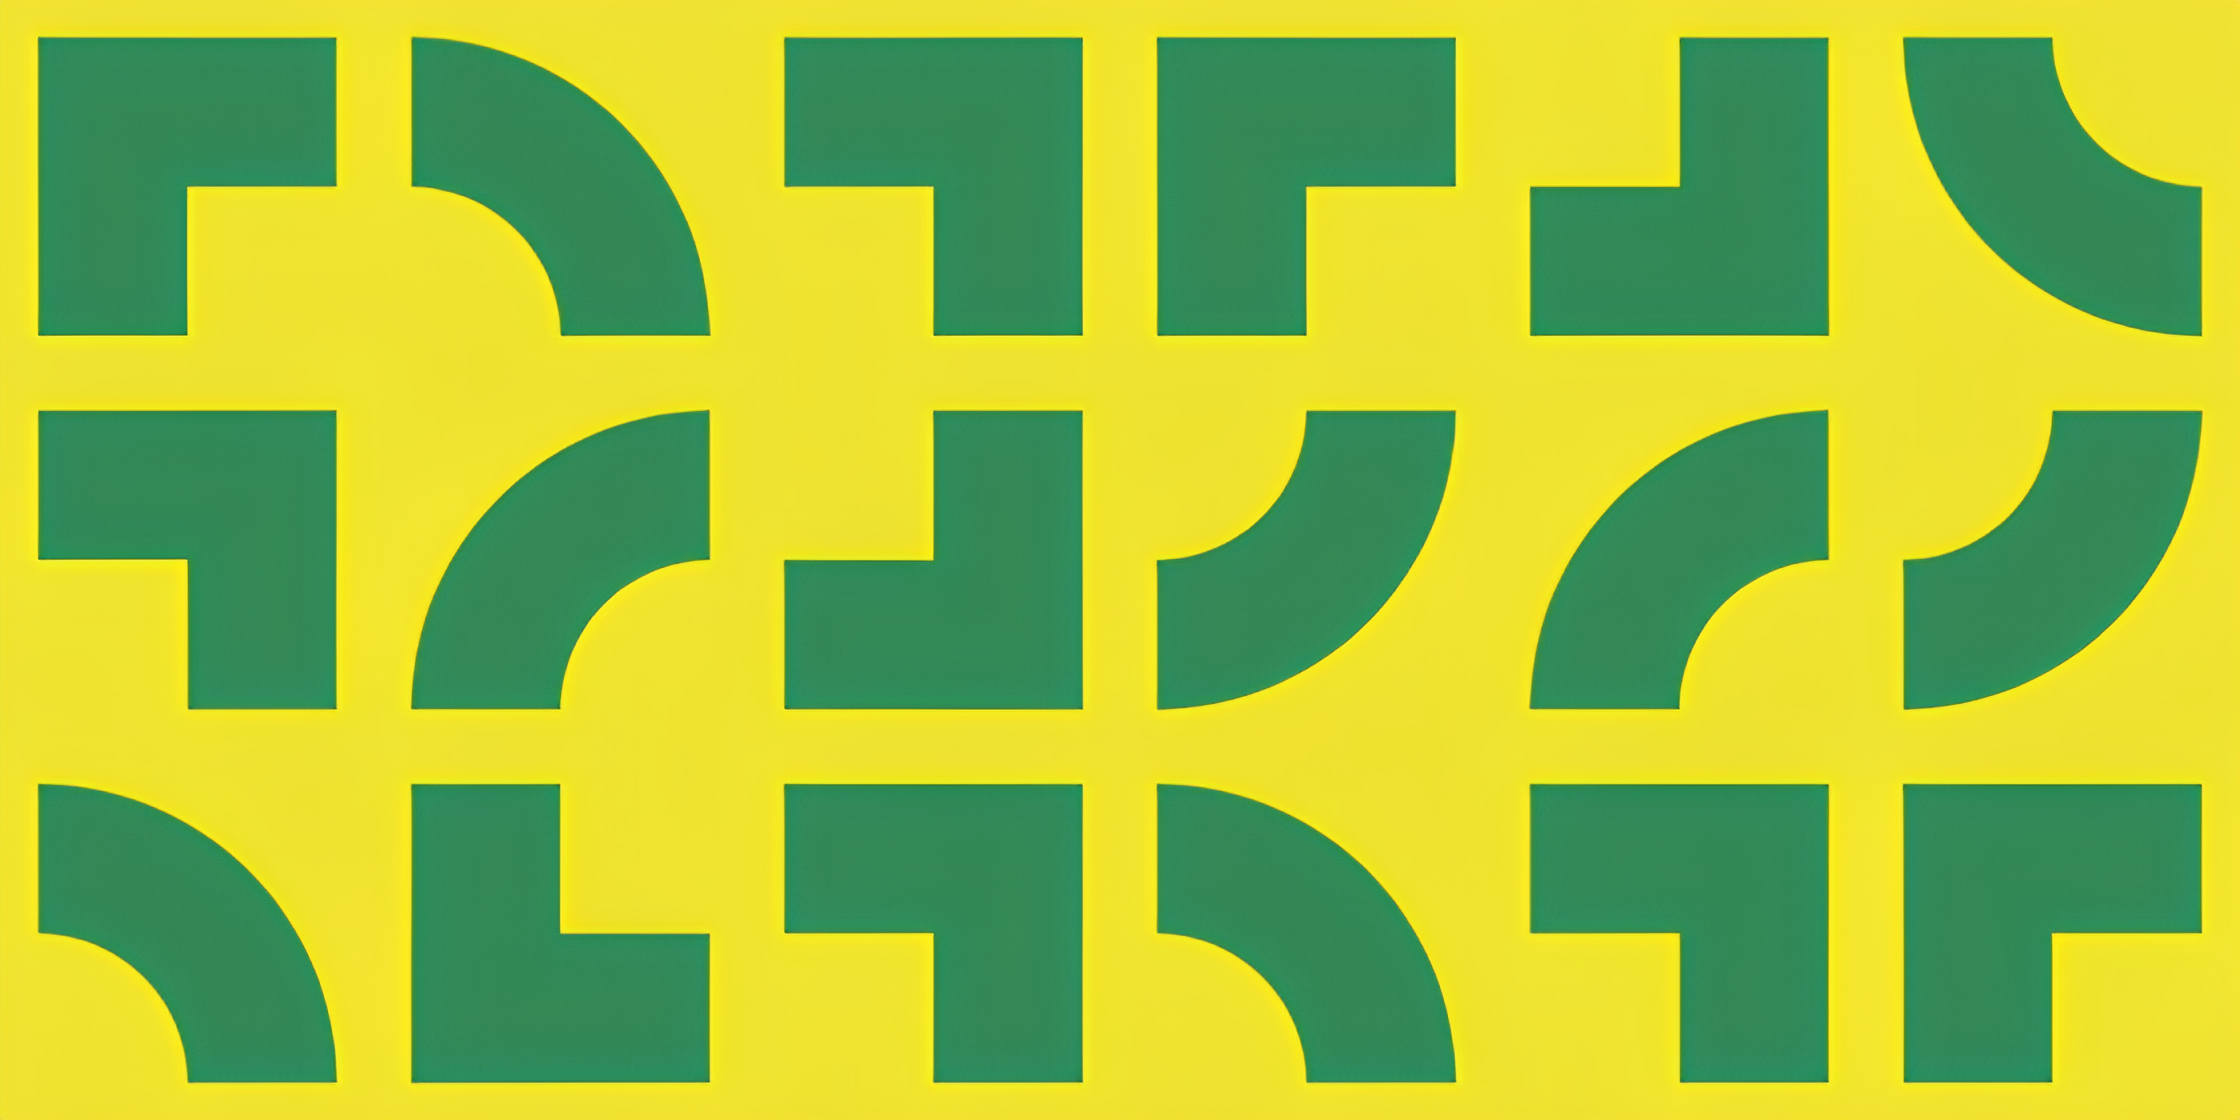

---

#### **Описание:**

**Fashion-MNIST** – аналог знаменитого датасета **MNIST**, который состоит не из рукописных символов, а из предметов одежды. Он был создан, чтобы актуализировать учебные задачи в компьютерном зрении и приблизить их к реальности.

Каждое изображение представляет собой набор их $784$ пикселей ($28$ x $28$). Каждый пиксель принимает значение от $0$ до $255$, обозначая его цвет в черно-белой шкале.

---

#### **Постановка задачи:**

В данном проекте необходимо построить модель, классифицирующую изображения с одеждой, построенную на датасете *Fashion-MNIST*.

---


#### **Основные цели:**

* Сформировать набор данных на основе предоставленных источников информации;

* Провести первичный анализ данных, чтобы определить наличие *NaN* значений;

* Провести подготовку данных к обучению модели;

* Построить модель, классифицирующую изображения с одеждой.

---


#### **Этапы работы над проектом:**

Проект будет состоять из пяти частей:

`1.` *Базовый анализ и знакомство с данными*;

`2.` *Очистка данных*;

`3.` *Подготовка данных*;

`4.` *Machine Learning*;

`5.` *Вывод*.

---

**Импортируем необходимые библиотеки:**

In [108]:
# Для работы с данными
import pandas as pd
import numpy as np


# Для построения графиков
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


# Для построения модели
from sklearn import model_selection
from sklearn import metrics
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model

**Загрузка данных:**

In [109]:
# Загружаем тренеровочную и тестовую выборки
fmnist_train_data = pd.read_csv('data/fmnist_train.csv')
fmnist_test_data = pd.read_csv('data/fmnist_test.csv')


# Выводим размерности
print(f'Размер тренеровочной выборки: {fmnist_train_data.shape}')
print(f'Размер тестовой выборки: {fmnist_test_data.shape}')

Размер тренеровочной выборки: (17040, 786)
Размер тестовой выборки: (10000, 785)


## <CENTER> **`1.` Базовый анализ и знакомство с данными**

На данном этапе изучим информацию предоставленных данных.

#### $1.1$

**Выведем информацию по таблицам.**

Создаём функцию:

In [110]:
# Создадим функцию для вывода информации по датасету
def check_data_inf(data, data_name = None, length1 = None, length2 = None):
    
    # Выводим размеры таблицы
    print(f'Данные таблицы "{data_name}" имеют следующую размерность:\n')
    print('Количество строк: {};\nКоличество признаков (столбцов): {}.'.format(data.shape[0], data.shape[1]))
    print('-' * length1)

    # Выведем первые пять строк 
    display(data.head())
    print('-' * length2)

Выводим результат:

In [111]:
# Выводим информацию по полученным таблицам при помощи функции 'check_data_inf'
check_data_inf(
    data = fmnist_train_data,
    data_name = 'fmnist_train_data',
    length1 = 40,
    length2 = 150
)

print('\n\n')

check_data_inf(
    data = fmnist_test_data,
    data_name = 'fmnist_test_data',
    length1 = 40,
    length2 = 150
)

Данные таблицы "fmnist_train_data" имеют следующую размерность:

Количество строк: 17040;
Количество признаков (столбцов): 786.
----------------------------------------


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,Id
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0,2
3,0,0,0,0,1,2,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


------------------------------------------------------------------------------------------------------------------------------------------------------



Данные таблицы "fmnist_test_data" имеют следующую размерность:

Количество строк: 10000;
Количество признаков (столбцов): 785.
----------------------------------------


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,Id
0,0,0,0,0,0,0,0,9,8,0,...,87,56,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,14,53,99,17,...,0,0,0,63,53,31,0,0,0,2
3,0,0,0,0,0,0,0,0,0,161,...,126,140,0,133,224,222,56,0,0,3
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


------------------------------------------------------------------------------------------------------------------------------------------------------


#### **Основные характеристики:**

Обучающая выборка содержит $786$ столбцов, где первый (`label`) – принадлежность изображения к классу, а последний – его уникальный номер (`id`). Остальные столбцы – пиксели изображения.

Тестовая выборка (на основе которой должно быть получено исследование) содержит все те же столбцы, кроме `label`.

*Расшифровка классов (`label`), к которым принадлежат изображения:*

* `0 T-shirt/top` – футболка;

* `1 Trouser` – брюки;

* `2 Pullover` – свитер;

* `3 Dress` – платье;

* `4 Coat` – пальто;

* `5 Sandal` – сандалия;

* `6 Shirt` – рубашка;

* `7 Sneaker` – кроссовок;

* `8 Bag` – сумка;

* `9 Ankle boot` – сапог.

---

#### $1.2$

Выведем информацию по признакам:

In [112]:
# Вывод таблицы 'fmnist_train_data'
print('Информация датасета "fmnist_train_data":\n')
display(fmnist_train_data.info())
print('-' * 40)
print()


# Вывод таблицы 'fmnist_test_data'
print('Информация датасета "fmnist_test_data":\n')
display(fmnist_test_data.info())
print('-' * 40)

Информация датасета "fmnist_train_data":

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17040 entries, 0 to 17039
Columns: 786 entries, label to Id
dtypes: float64(424), int64(362)
memory usage: 102.2 MB


None

----------------------------------------

Информация датасета "fmnist_test_data":

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, pixel1 to Id
dtypes: int64(785)
memory usage: 59.9 MB


None

----------------------------------------


Так как обе таблицы имеют слишком большую размерность, вывести всю информацию не получится.

#### $1.3$

**Подсчитаем количество типов данных по признакам.**

Создаём функцию для подсчёта:

In [113]:
# Создаём функцию для рассчёта количества типов по признакам
def check_features_dtypes(data, data_name = None, length1 = None, length2 = None):
    
    # Подсчет количества признаков типа 'object', 'int64' и 'float64'      
    object_columns_count = data.select_dtypes(include = ['object']).shape[1]
    int64_columns_count = data.select_dtypes(include = ['int64']).shape[1]
    float64_columns_count = data.select_dtypes(include = ['float64']).shape[1]
    bool_columns_count = data.select_dtypes(include = ['bool']).shape[1]


    # Вывод результата
    print(f'В таблице "{data_name}" представлены признаки следующих типов:')
    print('-' * length1)
    print()

    print(f"Количество признаков типа 'object': {object_columns_count}")
    print(f"Количество признаков типа 'int64': {int64_columns_count}")
    print(f"Количество признаков типа 'float64': {float64_columns_count}")
    print(f"Количество признаков типа 'bool': {bool_columns_count}")
    print('-' * length2)

Выводим результат:

In [114]:
# Выводим данные таблиц 'fmnist_train_data' и 'fmnist_test_data' 
check_features_dtypes(
    data = fmnist_train_data,
    data_name = 'fmnist_train_data',
    length1 = 70,
    length2 = 40
)

print('\n\n')

check_features_dtypes(
    data = fmnist_test_data,
    data_name = 'fmnist_test_data',
    length1 = 70,
    length2 = 40
)

В таблице "fmnist_train_data" представлены признаки следующих типов:
----------------------------------------------------------------------

Количество признаков типа 'object': 0
Количество признаков типа 'int64': 362
Количество признаков типа 'float64': 424
Количество признаков типа 'bool': 0
----------------------------------------



В таблице "fmnist_test_data" представлены признаки следующих типов:
----------------------------------------------------------------------

Количество признаков типа 'object': 0
Количество признаков типа 'int64': 785
Количество признаков типа 'float64': 0
Количество признаков типа 'bool': 0
----------------------------------------


#### $1.4$

Посмотрим на распределение классов, для этого построим график `barplot`:

------------------------------------------------------------------------------------------------------------------------------------------------------
Визуализация распределения классов:


C:\Users\User\AppData\Local\Temp\ipykernel_12168\927071546.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


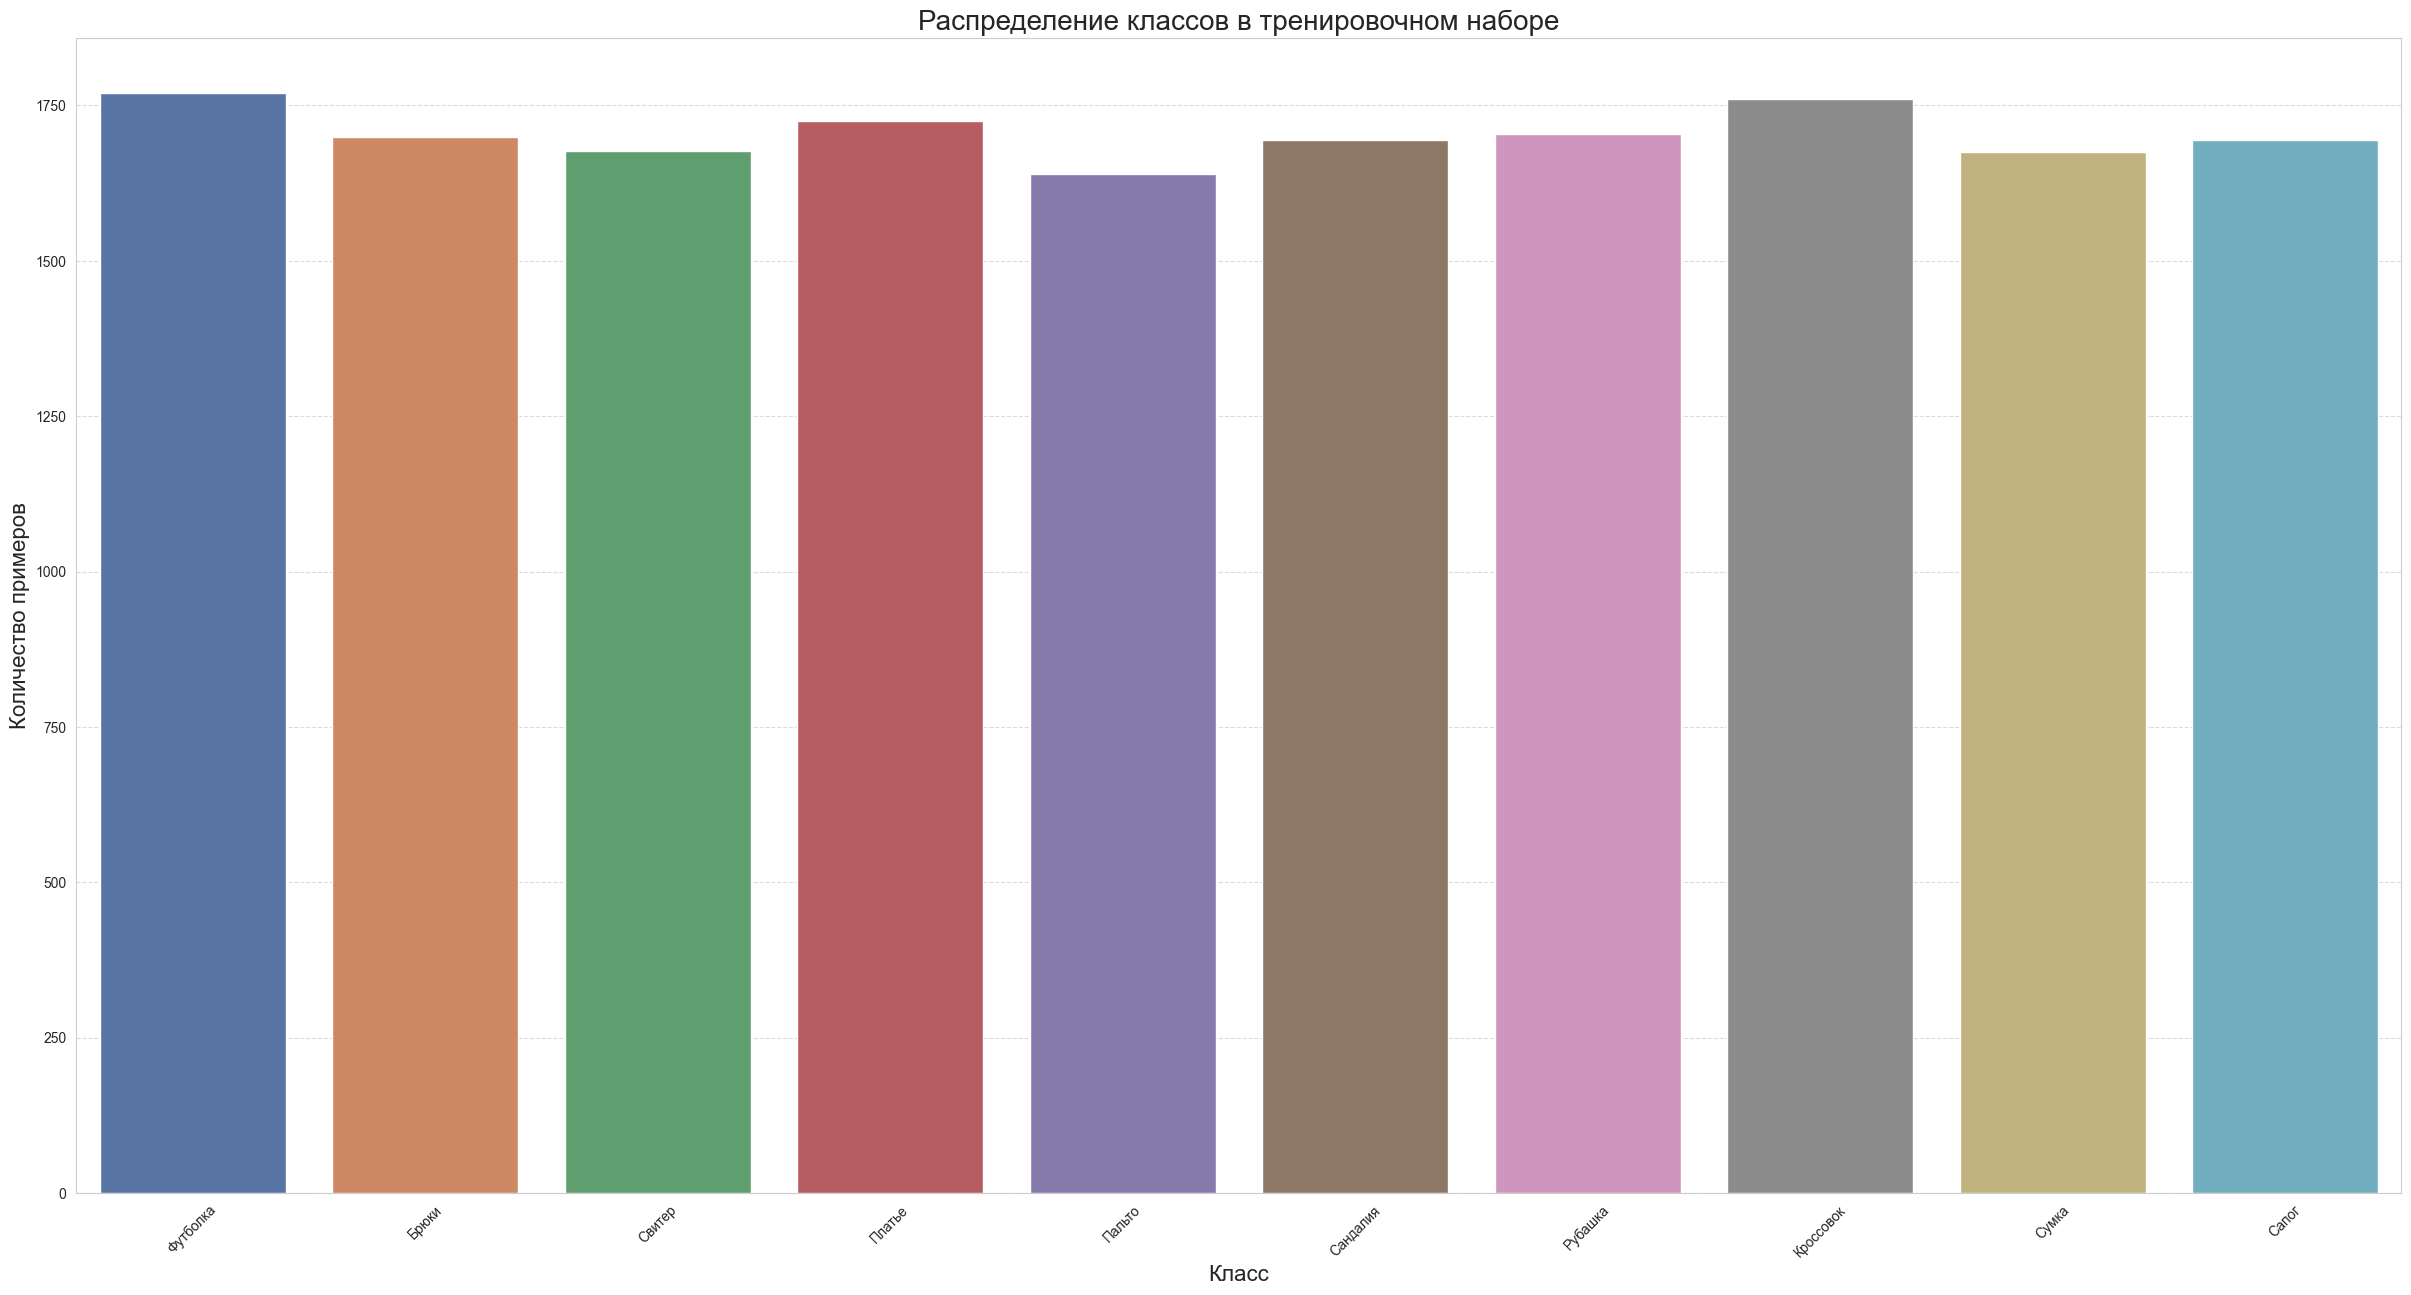

Количество примеров для каждого класса:
----------------------------------------

Футболка: 1770
Брюки: 1700
Свитер: 1677
Платье: 1725
Пальто: 1639
Сандалия: 1695
Рубашка: 1704
Кроссовок: 1761
Сумка: 1675
Сапог: 1694
--------------------


In [115]:
# Создаём словарь для меток классов
class_names = {
    0: 'Футболка',
    1: 'Брюки',
    2: 'Свитер',
    3: 'Платье',
    4: 'Пальто',
    5: 'Сандалия',
    6: 'Рубашка',
    7: 'Кроссовок',
    8: 'Сумка',
    9: 'Сапог'
}


# Заглавие графика
print('-' * 150)
print('Визуализация распределения классов:')



# Подсчет количества примеров для каждого класса
class_counts = fmnist_train_data['label'].value_counts().sort_index()

# Задаём стиль графика
sns.set_style('whitegrid')

# Задаём размер графика
plt.figure(figsize = (30, 15))

# Построение гистограммы
sns.barplot(
    x = class_counts.index, 
    y = class_counts.values,
    palette = 'deep',
    legend = False
)

# Настройка полотна
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(ticks=range(10), labels=[class_names[i] for i in range(10)], rotation=45)
plt.title('Распределение классов в тренировочном наборе', fontsize = 20)
plt.xlabel('Класс', fontsize = 16)
plt.ylabel('Количество примеров', fontsize = 16)
plt.show()



# Вывод количества примеров
print('Количество примеров для каждого класса:')
print('-' * 40)
print()


for idx, count in class_counts.items():
    print(f'{class_names[idx]}: {count}')
print('-' * 20)

**Вывод:**

Из полученного графика видно, что классы имеют практически нормальное распределение. Поэтому балансировка классов не требуется.

## <CENTER> **`2.` Очистка данных**

На данном этапе выявим и очистим данные от пропусков, дубликатов и выбросов.

#### $2.1$

**Проверим данные на наличие пропусков.**

Создаём $2$ функции для рассчёта пропусков и построения тепловой карты:

In [116]:
# Создаём функцию для подсчёта суммарного количества пропусков
def missing_values_count(data, data_name = None, length = None):
    
    # Выводим суммарное количество пропусков
    print('Суммарное количество пропусков в таблице "{}": {} \n'.format(data_name, data.isnull().sum().sum()))

    # Выводим признаки с сумрным количеством пропусков
    print('Информация по количествам пропусков: \n\n{} \n'.format(data.isnull().sum()))
    print('-' * length)




# Построим тепловую карту пропусков
# Создаём функцию отображения пропущенных значений на тепловой карте
def missing_values_heatmap(data):
    
    # Рассчитываем количество пропусков
    cols_null_persent = data.isnull().mean() * 100
    cols_with_null = cols_null_persent[cols_null_persent > 0].sort_values(ascending = False)
    print(f'Информация по количествам пропусков в процентах:\n\n{cols_with_null}')
    print('-' * 50)
    
    # Задаём параметры графика
    colors = sns.color_palette('coolwarm')
    fig = plt.figure(figsize = (30, 13))
    cols = cols_with_null.index
    
    # Строим тепловую карту
    ax = sns.heatmap(
        data = data[cols].isnull(),
        cmap = sns.color_palette(colors)
    )
    
    # Задаём название графика
    plt.title('Тепловая карта пропущенных значений', fontsize = 20)
    
    return ax

Выводим результаты тренировочной выборки:

Суммарное количество пропусков в таблице "fmnist_train_data": 424 

Информация по количествам пропусков: 

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel781    1
pixel782    1
pixel783    1
pixel784    1
Id          0
Length: 786, dtype: int64 

----------------------------------------------------------------------


Информация по количествам пропусков в процентах:

pixel361    0.005869
pixel652    0.005869
pixel650    0.005869
pixel649    0.005869
pixel648    0.005869
              ...   
pixel499    0.005869
pixel498    0.005869
pixel497    0.005869
pixel496    0.005869
pixel784    0.005869
Length: 424, dtype: float64
--------------------------------------------------


<Axes: title={'center': 'Тепловая карта пропущенных значений'}>

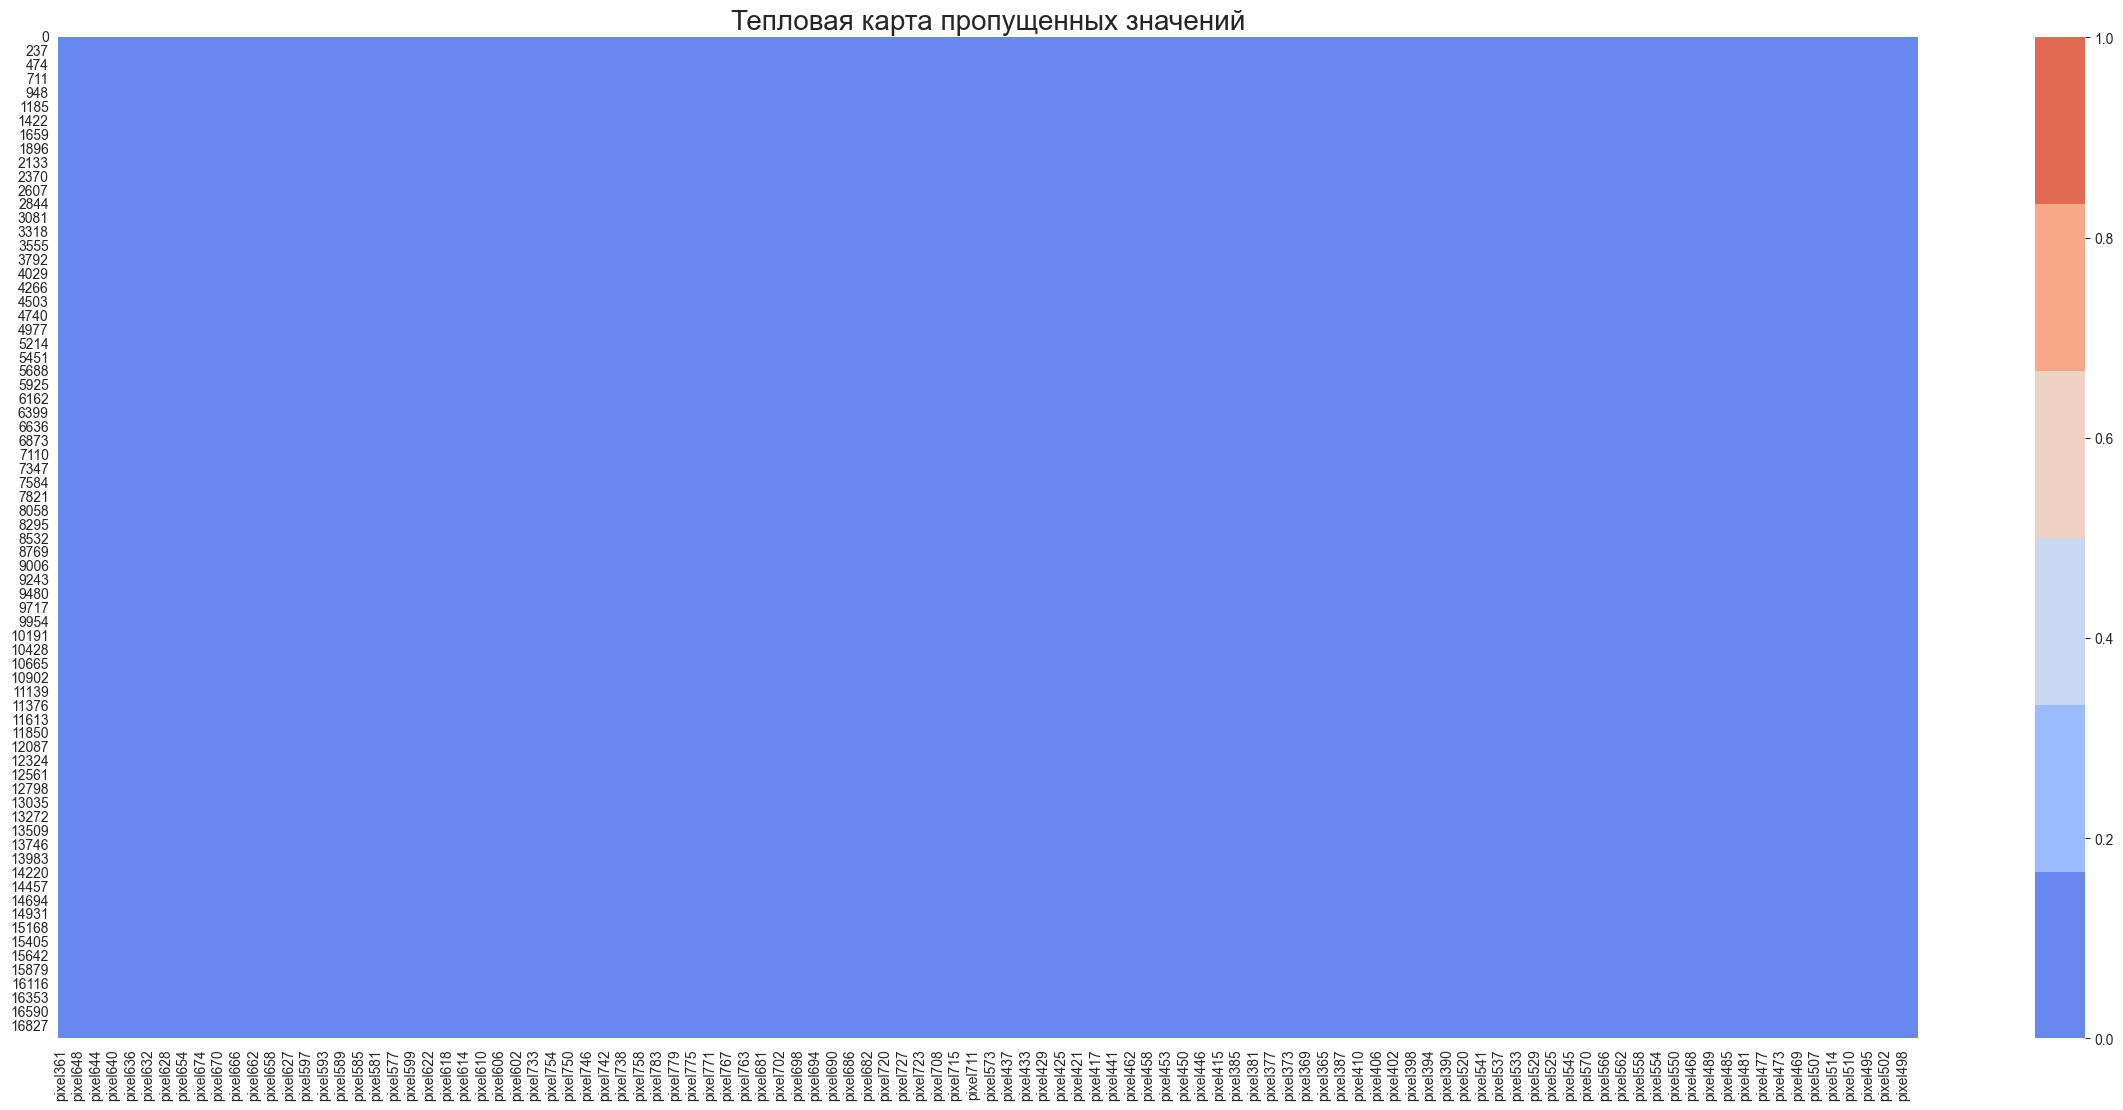

In [117]:
# Выводим количество пропусков
missing_values_count(
    data = fmnist_train_data,
    data_name = 'fmnist_train_data',
    length = 70
)

print('\n')

# Выводим тепловую карту
missing_values_heatmap(data = fmnist_train_data)

Выводим результаты тестовой выборки:

In [118]:
# Выводим количество пропусков
missing_values_count(
    data = fmnist_test_data,
    data_name = 'fmnist_test_data',
    length = 70
)

Суммарное количество пропусков в таблице "fmnist_test_data": 0 

Информация по количествам пропусков: 

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Id          0
Length: 785, dtype: int64 

----------------------------------------------------------------------


**Вывод:**

Из полученных рассчётов видно, что пропуски имеет только тренировочный датасет, а общее количество пропущенных значений не превышает $0.1$%.

Заменим пропуски медианным значением:

In [119]:
# Обработка пропусков: замена пропусков медианным значением для каждого столбца
for column in fmnist_train_data.columns:
    if fmnist_train_data[column].isnull().sum() > 0:
        fmnist_train_data[column] = fmnist_train_data[column].fillna(fmnist_train_data[column].median())
        
        
        
# Выводим количество пропусков после обработки
missing_values_count(
    data = fmnist_train_data,
    data_name = 'fmnist_train_data',
    length = 70
)

Суммарное количество пропусков в таблице "fmnist_train_data": 0 

Информация по количествам пропусков: 

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Id          0
Length: 786, dtype: int64 

----------------------------------------------------------------------


## <CENTER> **`3.` Подготовка данных**

На данном этапе произведём преобразование и разделение данных.

#### $3.1$

Для начала, разделим выборку на тренировочную и тестовую:

In [120]:
# Выделение тренировочной выборки
X_train = fmnist_train_data.drop(columns=['label', 'Id'], axis=1).values
y_train = fmnist_train_data['label'].values

# Выделение тестовой выборки
X_test = fmnist_test_data.drop(columns=['Id'], axis=1).values
test_ids = fmnist_test_data['Id'].values



# Выводим размерности
print('Размер тренировочной выборки: {}'.format(X_train.shape))
print('Размер тестовой выборки: {}'.format(X_test.shape))

Размер тренировочной выборки: (17040, 784)
Размер тестовой выборки: (10000, 784)


#### $3.2$

Произведём нормализацию и преобразование данных:

In [121]:
# Нормализация тренировочной и тестовой выборки
X_train = X_train / 255.0
X_test = X_test / 255.0


# Преобразуем вектор правильных ответов при помощи метода 'to_categorical'
y_train = to_categorical(y_train, num_classes = 10)

#### $3.3$

Теперь разделим тренировочную выборку на тренировочную и валидационную в соотношении $80$/$20$: 

In [122]:
# Разделение на обучающую и валидационную выборки
X_train, X_valid, y_train, y_valid = model_selection.train_test_split(
    X_train, y_train,
    test_size = 0.2,
    random_state = 42
)



# Выводим размерности
print('Размер тренировочной выборки: {}'.format(X_train.shape))
print('Размер тестовой выборки: {}'.format(X_valid.shape))

Размер тренировочной выборки: (13632, 784)
Размер тестовой выборки: (3408, 784)


## <CENTER> **`4.` Machine Learning**

На данном этапе построим модель глубокого обучения, классифицирующую изображения с одеждой.

#### $4.1$

Строим модель свёрточной нейронной сети:

In [123]:
# Построение модели CNN
CNN_model = Sequential([
    tf.keras.layers.Reshape((28, 28, 1), input_shape = (784,)),
    tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation = 'softmax')
])


# Компиляция модели
CNN_model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)


# Вывод структуры модели
CNN_model.summary()

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_5 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

#### $4.2$

Обучаем модель:

In [124]:
# Обучение модели
history = CNN_model.fit(
    X_train, y_train,
    epochs = 20,
    batch_size = 32,
    validation_data = (X_valid, y_valid),
    verbose = 1
)



# Оценка модели на валидационной выборке
valid_loss, valid_accuracy = CNN_model.evaluate(X_valid, y_valid)
print(f'Точность на валидационной выборке: {valid_accuracy:.4f}')

Epoch 1/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6131 - loss: 1.0940 - val_accuracy: 0.8046 - val_loss: 0.5109
Epoch 2/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7921 - loss: 0.5489 - val_accuracy: 0.8366 - val_loss: 0.4358
Epoch 3/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8250 - loss: 0.4624 - val_accuracy: 0.8627 - val_loss: 0.3841
Epoch 4/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8438 - loss: 0.4259 - val_accuracy: 0.8495 - val_loss: 0.3868
Epoch 5/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8529 - loss: 0.3873 - val_accuracy: 0.8691 - val_loss: 0.3632
Epoch 6/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8758 - loss: 0.3490 - val_accuracy: 0.8779 - val_loss: 0.3363
Epoch 7/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8761 - loss: 0.3395 - val_accuracy: 0.8718 - val_loss: 0.3383
Epoch 8/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8905 - loss: 0.3059 - val_accuracy: 0.

Строим визуализацию:

------------------------------------------------------------------------------------------------------------------------------------------------------
Визуализация процесса обучения:


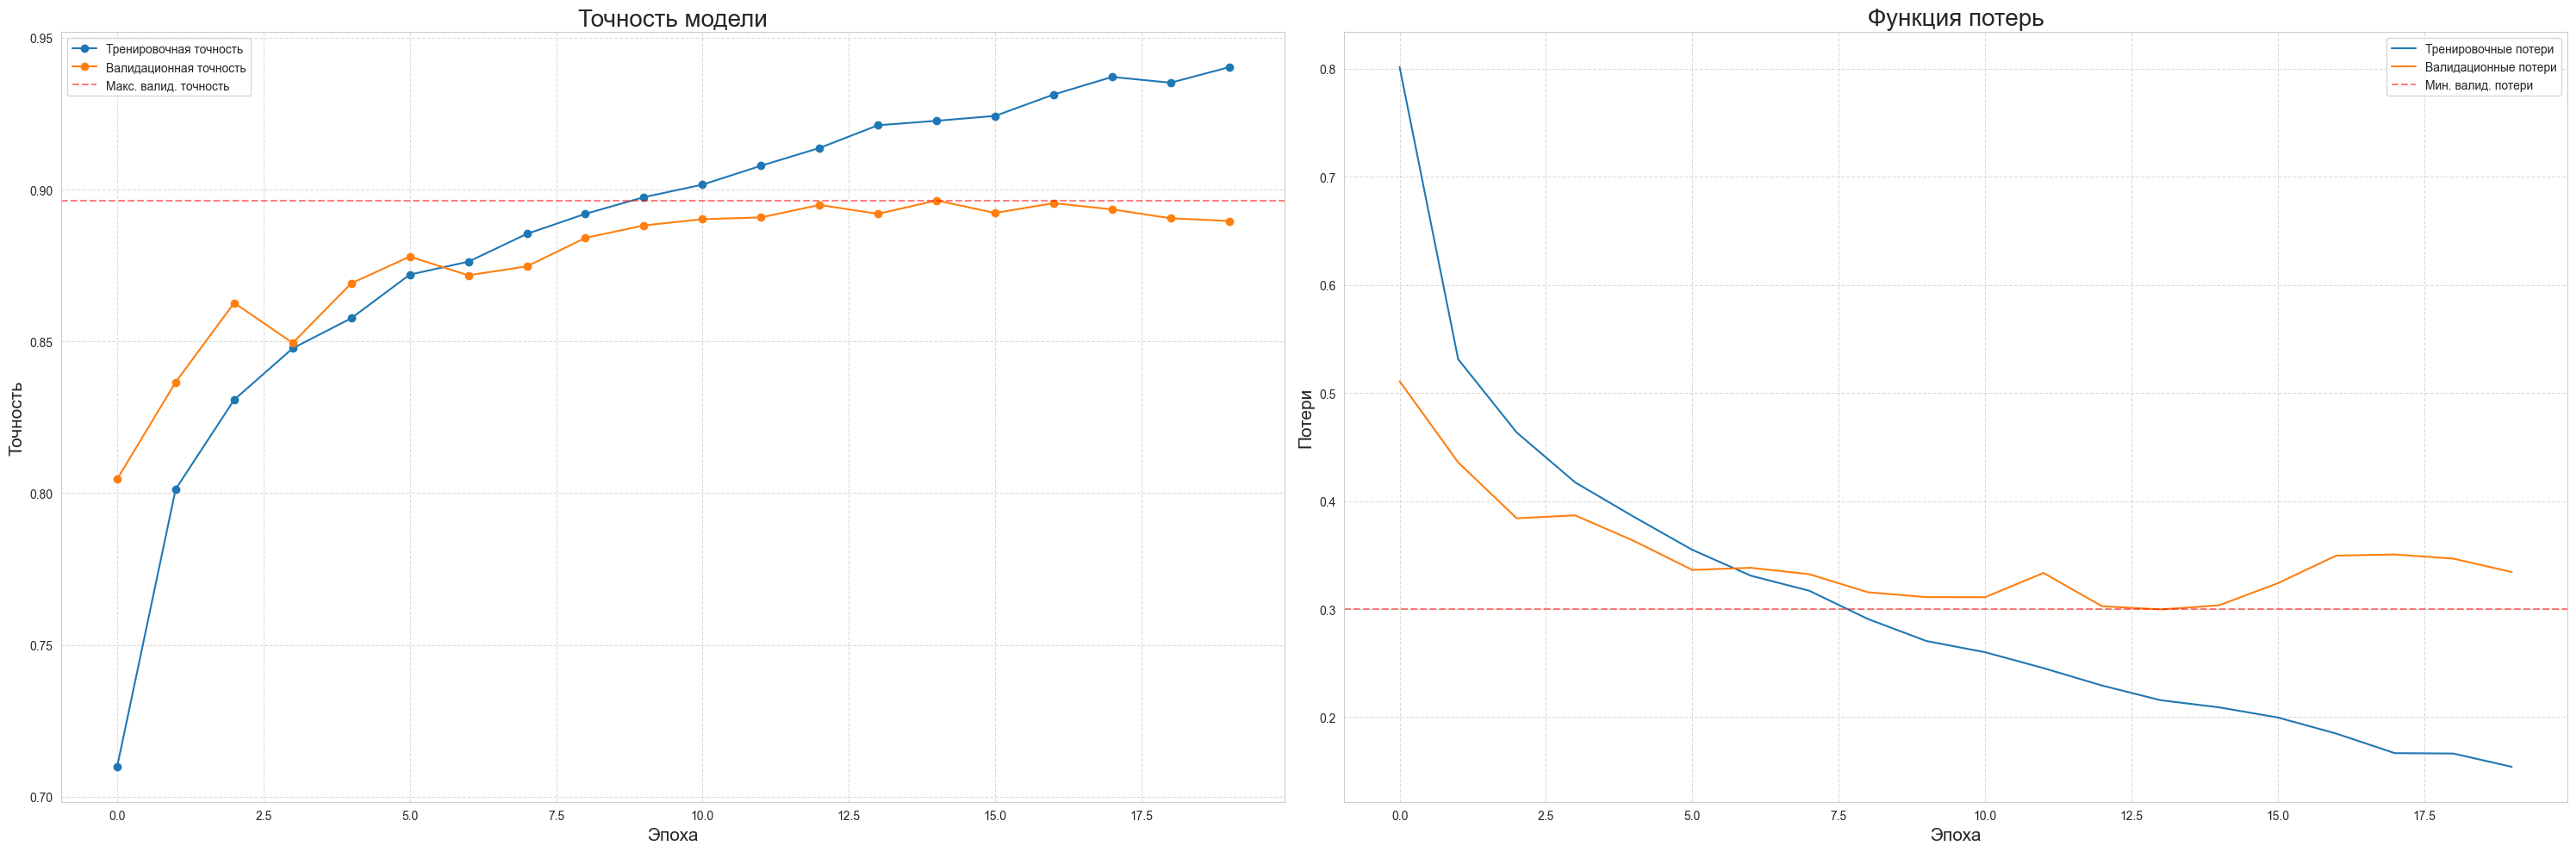

In [125]:
# Заглавие графика
print('-' * 150)
print('Визуализация процесса обучения:')



# Задаём размер графика
plt.figure(figsize = (30, 10))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label = 'Тренировочная точность', marker = 'o')
plt.plot(history.history['val_accuracy'], label = 'Валидационная точность', marker = 'o')
plt.axhline(y=max(history.history['val_accuracy']), color='r', linestyle='--', alpha=0.5, label='Макс. валид. точность')
plt.title('Точность модели', fontsize = 20)
plt.xlabel('Эпоха', fontsize = 15)
plt.ylabel('Точность', fontsize = 15)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.legend()
 
# График функции потерь
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label = 'Тренировочные потери')
plt.plot(history.history['val_loss'], label = 'Валидационные потери')
plt.axhline(y=min(history.history['val_loss']), color='r', linestyle='--', alpha=0.5, label='Мин. валид. потери')
plt.title('Функция потерь', fontsize = 20)
plt.xlabel('Эпоха', fontsize = 15)
plt.ylabel('Потери', fontsize = 15)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.legend()

# Выводим график
plt.show()

**Вывод:**

Модель быстро учится в первые $5$ эпох, но затем начинает переобучаться, и валидационные метрики (точность и потери) показывают колебания, что может быть связано с высоким `learning rate` или недостаточной регуляризацией.

#### $4.3$

Получение предсказаний:

In [126]:
# Производим предсказание на тестовой выборке
predictions = CNN_model.predict(X_test)
predicted_classes = np.argmax(predictions, axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Строим визуализацию:

------------------------------------------------------------------------------------------------------------------------------------------------------
Сетка изображений из тестового набора с предсказанными метками:


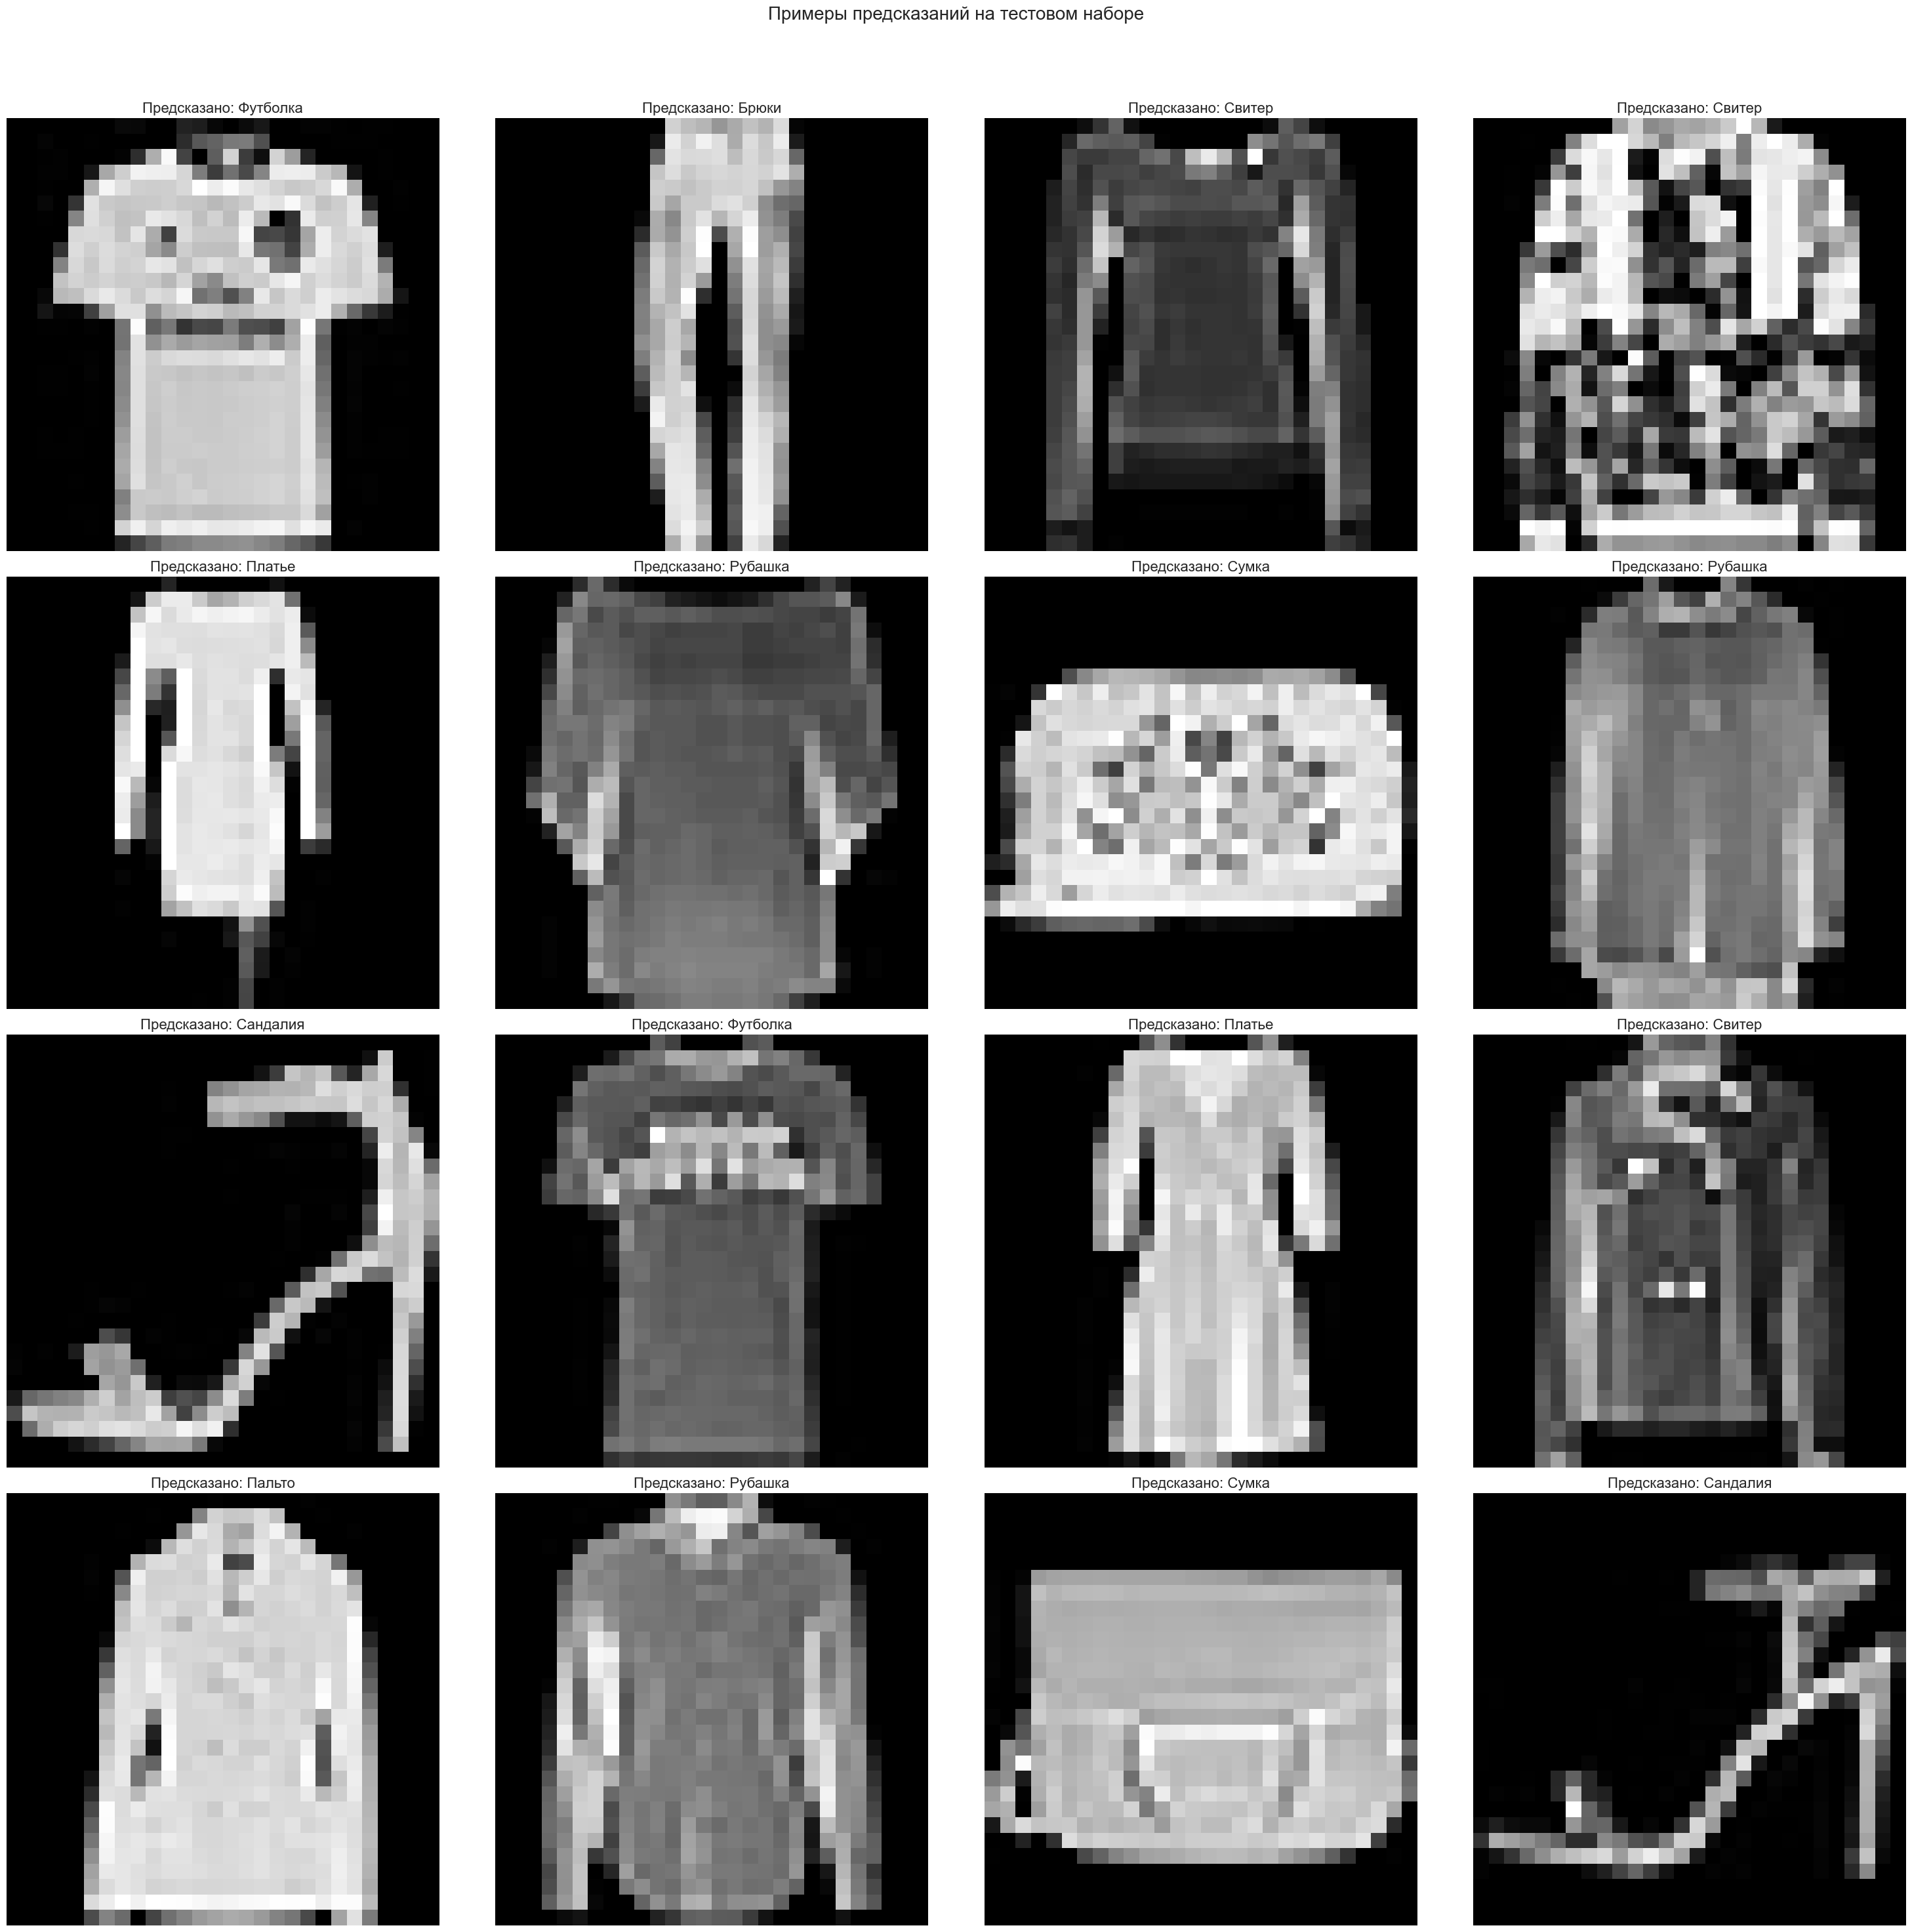

In [127]:
# Заглавие графика
print('-' * 150)
print('Сетка изображений из тестового набора с предсказанными метками:')



# Визуализация первых 16 предсказаний
plt.figure(figsize = (30, 30))

# Выводим 16 изображений
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap = 'gray')
    plt.title(f'Предсказано: {class_names[predicted_classes[i]]}', fontsize = 16)
    plt.axis('off')
    
# Офрмляем графики
plt.suptitle('Примеры предсказаний на тестовом наборе', fontsize = 20)
plt.tight_layout(rect = [0, 0, 1, 0.95])

# Выводим график
plt.show()

**Вывод:**

Во всех случаях модель правильно предсказала объекты на изображениях.

#### $4.4$

Используем валидационную выборку для оценки точности. Построим `confusion matrix` для анализа ошибок классификации:

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
------------------------------------------------------------------------------------------------------------------------------------------------------
Тепловая карта анализа ошибок классификации:


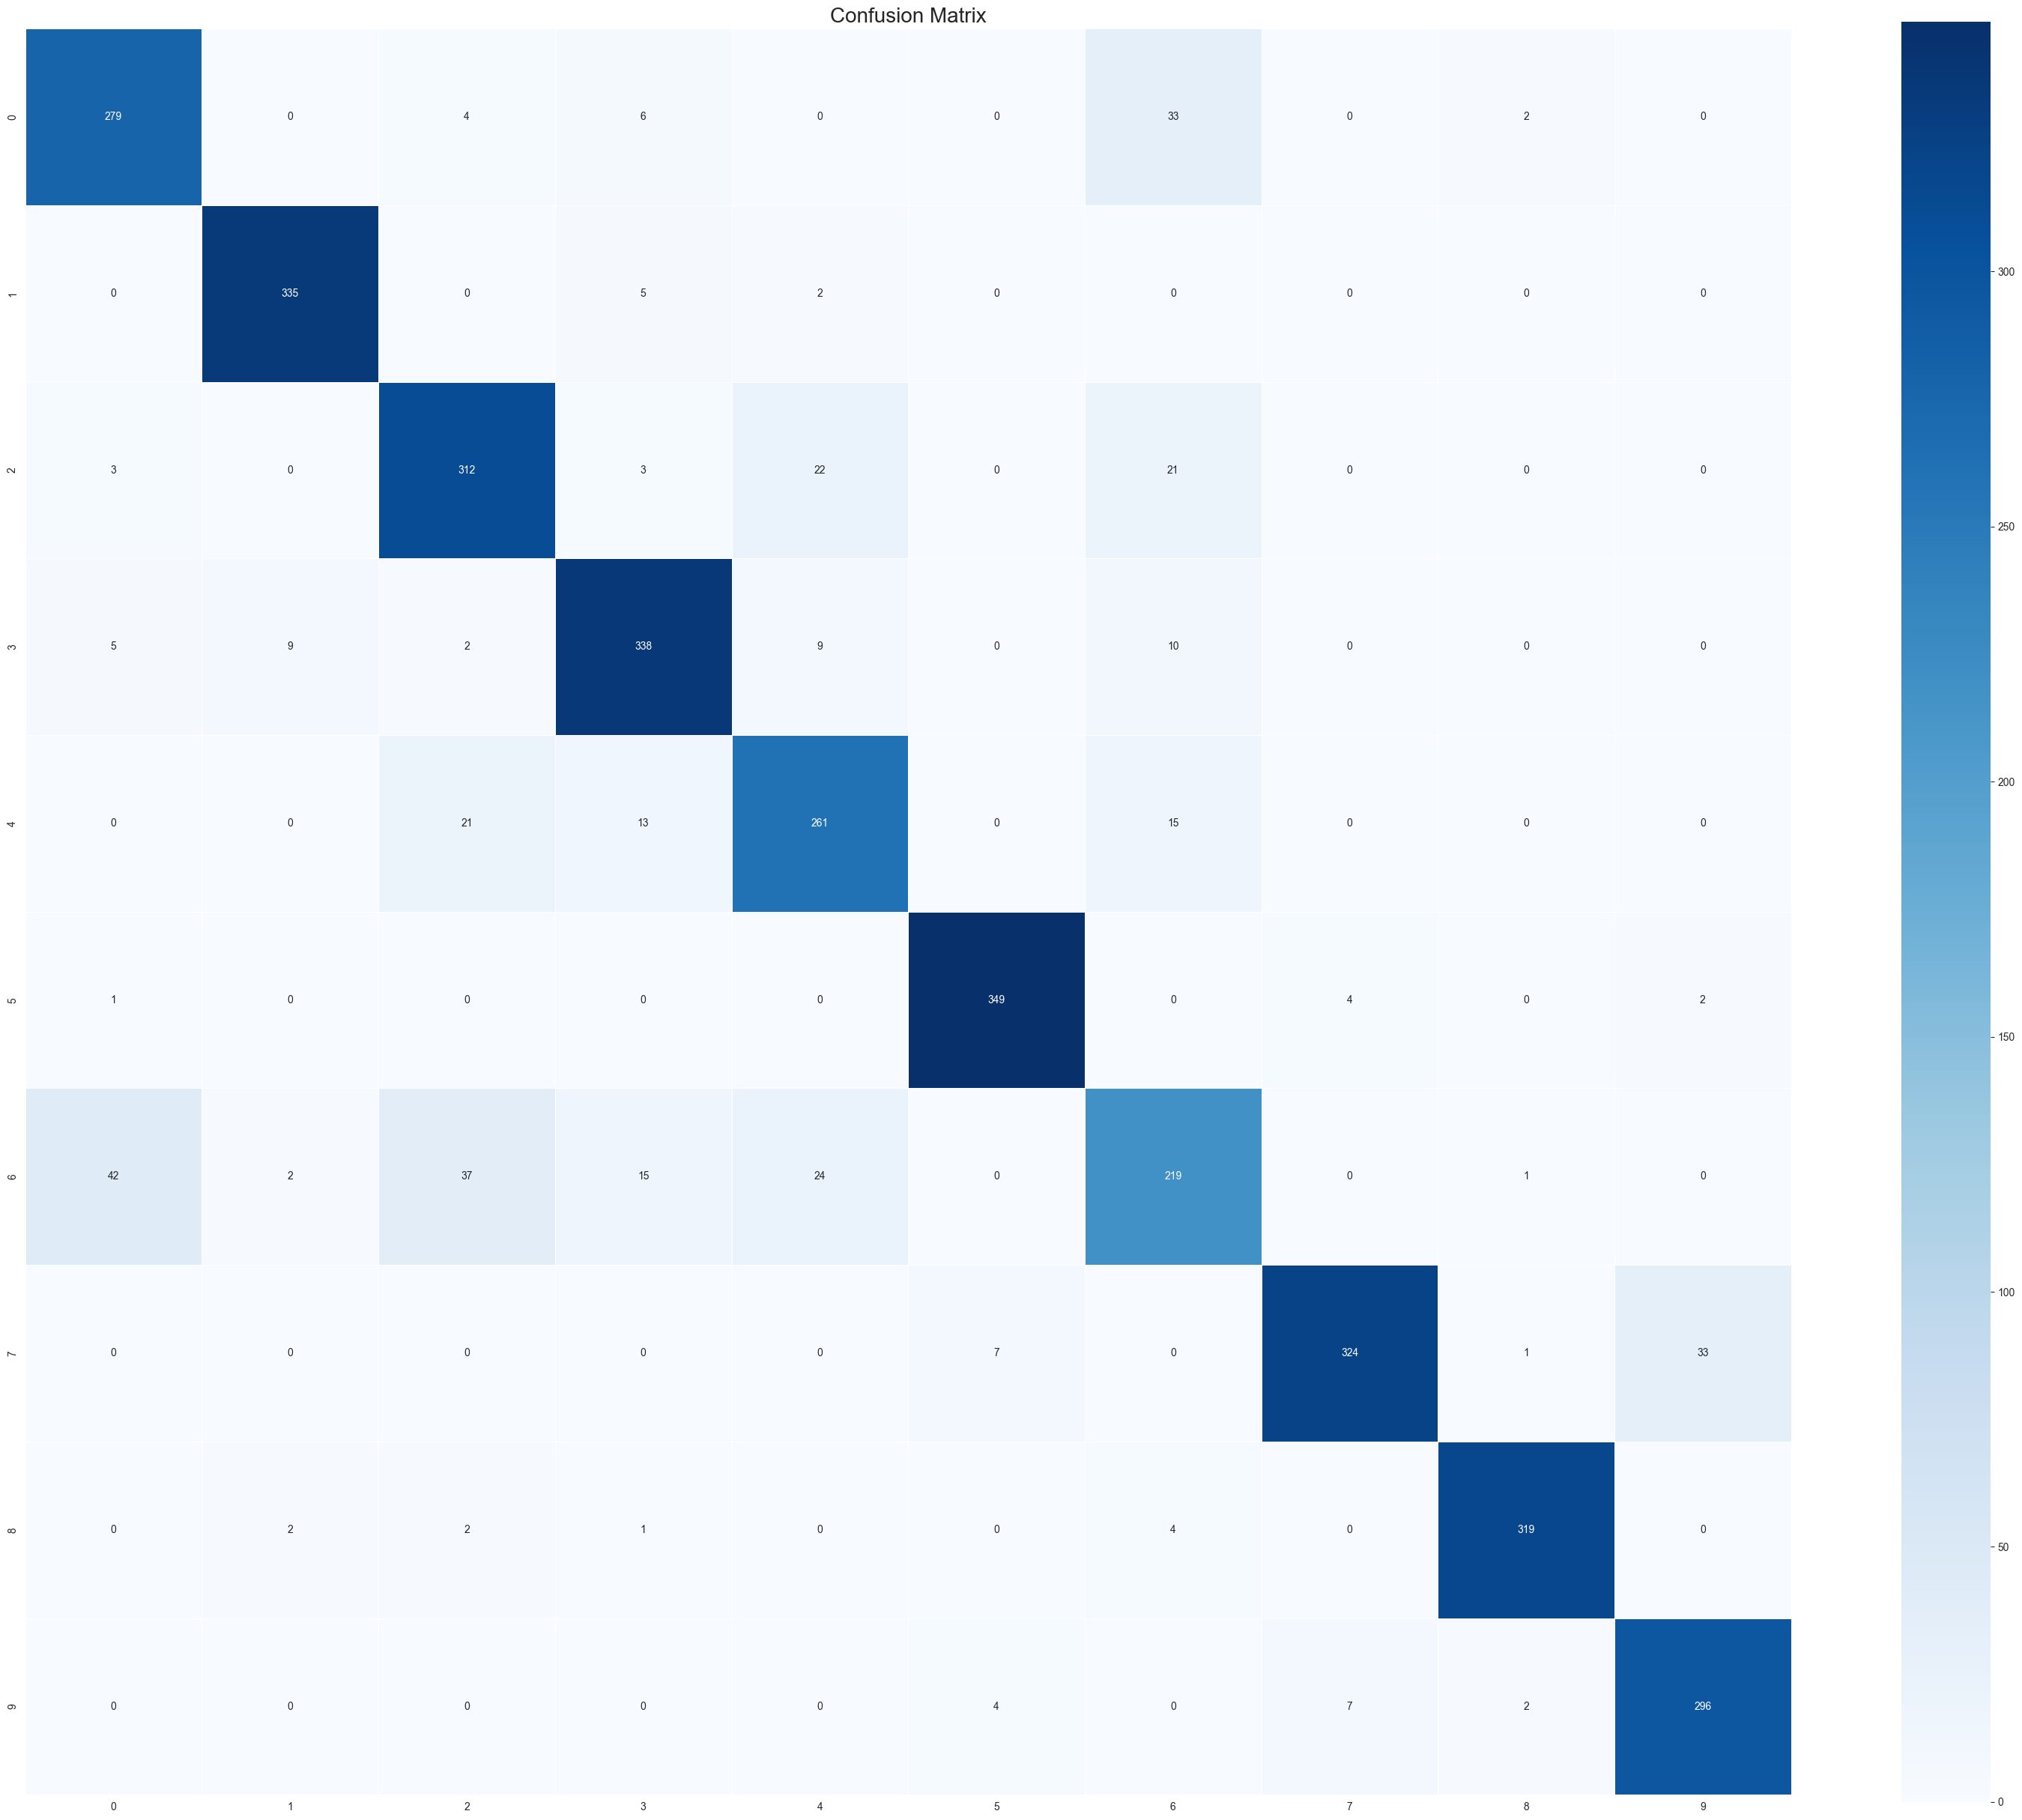

In [128]:
# Производим предсказание на валидационной выборке
y_valid_predict = CNN_model.predict(X_valid)
y_valid_predict_classes = np.argmax(y_valid_predict, axis = 1)
y_valid_true = np.argmax(y_valid, axis = 1)




# Заглавие графика
print('-' * 150)
print('Тепловая карта анализа ошибок классификации:')

# Строим 'confusion_matrix'
cm = metrics.confusion_matrix(y_valid_true, y_valid_predict_classes)

# Задаём размер полотна
plt.rcParams['figure.figsize'] = (30, 30)

# Строим тепловую карту
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    square = True,
    cbar_kws = {'shrink': .8},
    linewidths = 0.5
)

# Настраиваем параметры
plt.title('Confusion Matrix', fontsize = 20)
plt.tight_layout()
    
# Выводим график
plt.show()

Посмотрим предсказания на валидационной выборке:

------------------------------------------------------------------------------------------------------------------------------------------------------
Сетка изображений из валидационного набора с предсказанными метками:


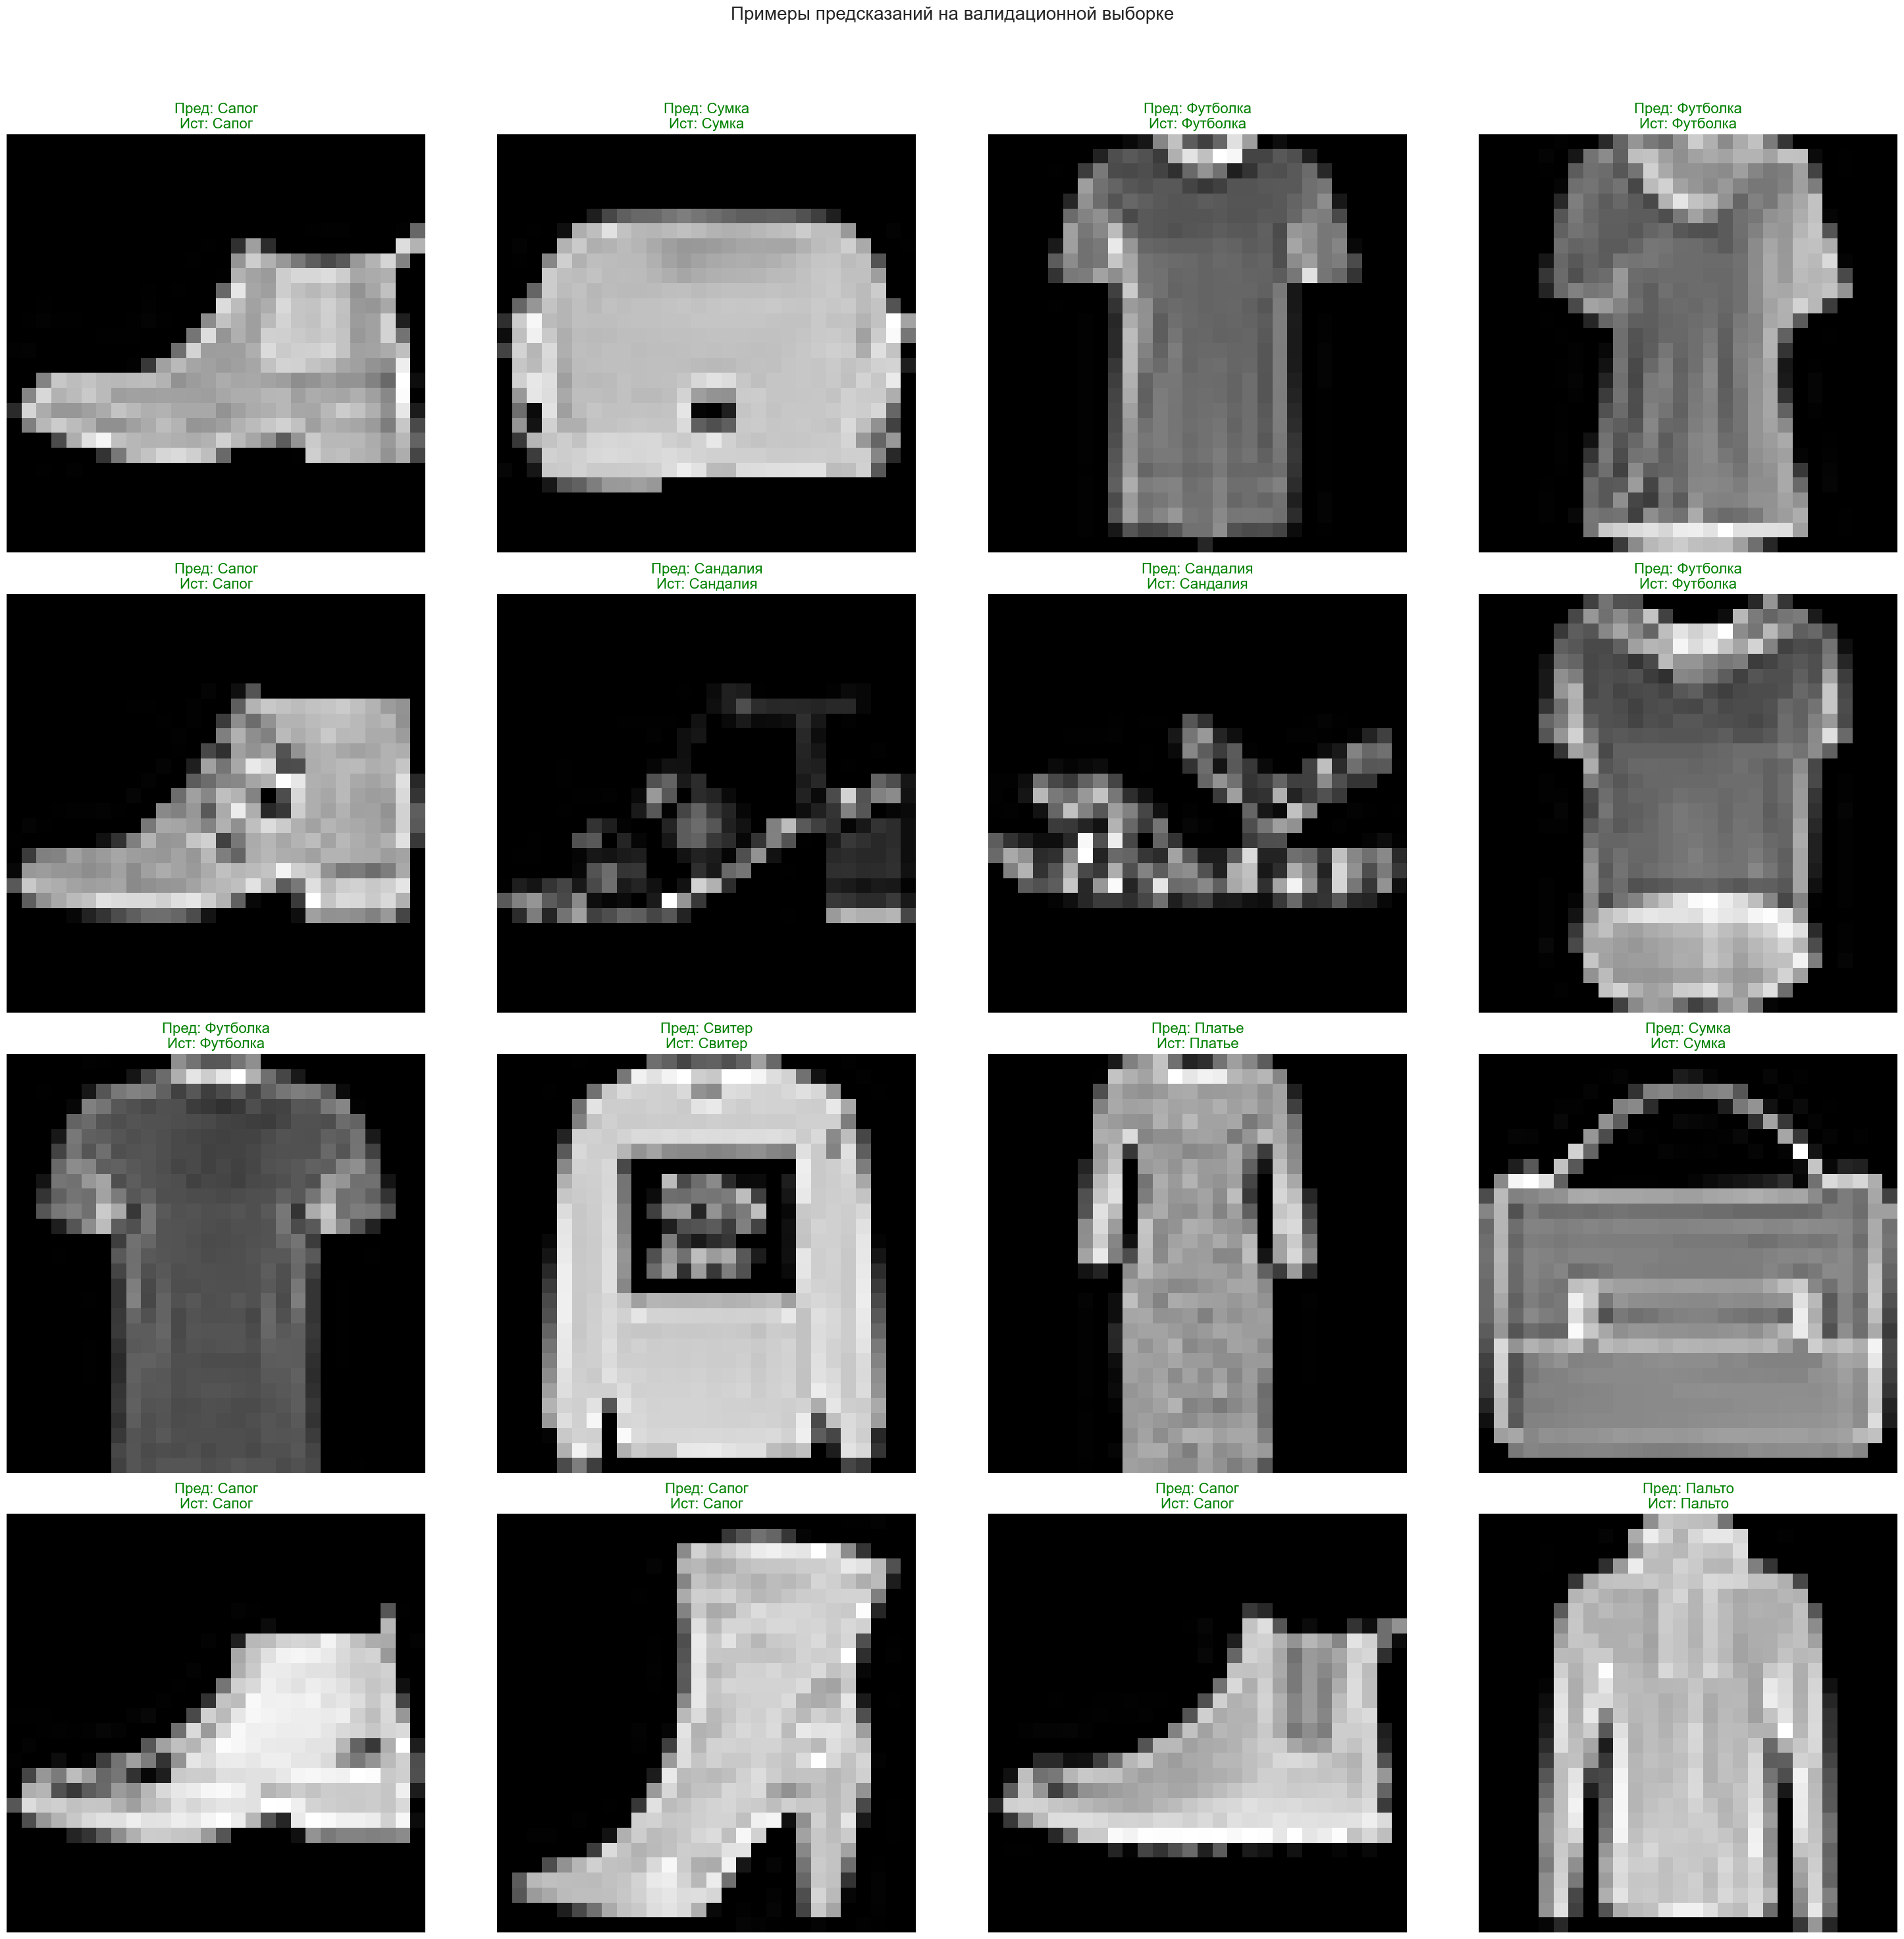

In [129]:
# Заглавие графика
print('-' * 150)
print('Сетка изображений из валидационного набора с предсказанными метками:')



# Визуализация первых 16 предсказаний
plt.figure(figsize = (30, 30))

# Выводим 16 изображений
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_valid[i].reshape(28, 28), cmap = 'gray')
    pred_label = class_names[y_valid_predict_classes[i]]
    true_label = class_names[y_valid_true[i]]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f'Пред: {pred_label}\nИст: {true_label}', fontsize = 16, color = color)
    plt.axis('off')
    
# Офрмляем графики
plt.suptitle('Примеры предсказаний на валидационной выборке', fontsize = 20)
plt.tight_layout(rect = [0, 0, 1, 0.95])

# Выводим график
plt.show()

**Вывод:**

Как видно из полученных результатов, модель не допустила ни одной ошибки.

#### $4.4$

**Сохраняем полученные результаты.**

Формируем *DataFrame*:

In [130]:
# Формирование файла с результатами
submission = pd.DataFrame({
    'Id': test_ids,
    'label': predicted_classes
})



# Выводим информацию по полученным таблицам при помощи функции 'check_data_inf'
check_data_inf(
    data = submission,
    data_name = 'submission df',
    length1 = 40,
    length2 = 15
)

Данные таблицы "submission df" имеют следующую размерность:

Количество строк: 10000;
Количество признаков (столбцов): 2.
----------------------------------------


,Id,label
0,0,0
1,1,1
2,2,2
3,3,2
4,4,3


---------------


Сохранение результатов:

In [131]:
# Сохранение результата
submission.to_csv('submission.csv', index = False)
print("Файл 'submission.csv' успешно сохранен!")

Файл 'submission.csv' успешно сохранен!


## <CENTER> **`5.` Вывод**

Подведём итоги по проделанной работе:

1. Проведена очистка данных: пропуски ($452$) в тренировочном датасете были заменены медианными значениями;
2. Данные нормализованы (пиксели приведены к диапазону $0$-$1$);
3. Построена свёрточная нейронная сеть с полносвязными слоями, пулингом и регуляризацией;
4. Модель обучена на $20$ эпохах, достигнута точность на тестовой выборке: $0.89914$;
5. Сделаны предсказания для тестовой выборки, результаты сохранены в `submission.csv`.